# Voxel Allegiance — Liu-Aligned

Quantifies voxel-level category reorganization in VOTC across time, using
Liu pipeline contrasts and pre-registered MNI zstats.

**Pipeline alignment:**
- Liu differential contrasts (cope 1=Face>Object, 2=House>Object, 3=Object>Scramble, -cope 13=Word>Face)
- Pre-registered MNI zstats from `13_register_zstats_mni.py`
- WTA threshold z > 2.326 (one-tailed p<.01)
- VOTC mask: Harvard-Oxford labels (MNI 2mm)

**Analyses:**
1. Winner-take-all (WTA) maps per voxel
2. Transition matrices T1→T2 (longitudinal)
3. Profile stability (cosine similarity)
4. Summed selectivity per category
5. WTA margin (confidence)
6. Relocating vs. resident category stability
7. Statistics — anatomical vs functional homolog frameworks
8. Summary table

## Setup & Configuration

In [1]:
import os, sys
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import t as t_dist
from collections import deque
import warnings
warnings.filterwarnings('ignore')

from nilearn import datasets as nl_datasets

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, get_sessions,
                           is_patient, get_sub_info, _load_csv)

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#E74C3C', 'house': '#3498DB',
              'object': '#2ECC71', 'word': '#F39C12',
              'none': '#BDC3C7'}

# Liu contrasts: (cope, negate). face=1, house=2, object=3, word=-13
LIU_CONTRASTS = {
    'face':   (1,  False),
    'house':  (2,  False),
    'object': (3,  False),
    'word':   (13, True),
}

WTA_THRESHOLD = 2.326   # one-tailed p<.01, matches Liu sum-sel

# Subject exclusions (match liu_recreation_csv_v2.py)
EXTRA_SKIP = {'sub-017', 'control083', 'control085'}
PRE_SURGERY_SESSIONS = {
    'sub-021': {'01'}, 'sub-045': {'01'}, 'sub-047': {'01'}, 'sub-049': {'01'},
    'sub-070': {'01'}, 'sub-073': {'01'}, 'sub-081': {'01'}, 'sub-086': {'01'},
    'sub-108': {'02'},
}

# Functional lateralization for functional-homolog comparisons
FUNCTIONAL_HEMI = {
    'face':   'r',
    'house':  None,   # bilateral — pool both hemispheres
    'object': None,
    'word':   'l',
}

OUT_DIR = os.path.join(processed_dir, 'group_results', 'voxel_allegiance_liu')
FIG_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Output: {OUT_DIR}')
print(f'WTA threshold: z > {WTA_THRESHOLD}')
print(f'Contrasts: {LIU_CONTRASTS}')

Output: /user_data/csimmon2/sym_pt/group_results/voxel_allegiance_liu
WTA threshold: z > 2.326
Contrasts: {'face': (1, False), 'house': (2, False), 'object': (3, False), 'word': (13, True)}


## Helpers — VOTC mask, MNI zstat loading, analyses

In [2]:
# ── VOTC mask (Harvard-Oxford, MNI 2mm), split by hemisphere ──────────
ho_atlas = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_img = ho_atlas.maps if isinstance(ho_atlas.maps, nib.Nifti1Image) else nib.load(ho_atlas.maps)
ho_data = ho_img.get_fdata()
ho_labels = ho_atlas.labels

VOTC_LABEL_NAMES = [
    'Temporal Fusiform Cortex, anterior division',
    'Temporal Fusiform Cortex, posterior division',
    'Temporal Occipital Fusiform Cortex',
    'Parahippocampal Gyrus, anterior division',
    'Parahippocampal Gyrus, posterior division',
    'Lingual Gyrus',
    'Lateral Occipital Cortex, superior division',
    'Lateral Occipital Cortex, inferior division',
]

_votc_full = np.zeros(ho_data.shape, dtype=bool)
for name in VOTC_LABEL_NAMES:
    matches = [i for i, l in enumerate(ho_labels) if name in l]
    if matches:
        _votc_full |= (ho_data == matches[0])

# Hemisphere split (FSL HO is in MNI; x-midline at voxel ~45 in 2mm 91x109x91)
mid_x = ho_data.shape[0] // 2
VOTC_MASK_LH = _votc_full.copy()
VOTC_MASK_LH[:mid_x] = False     # MNI x>0 → LH in FSL convention (radiological)
VOTC_MASK_RH = _votc_full.copy()
VOTC_MASK_RH[mid_x:] = False
MNI_AFFINE = ho_img.affine

print(f'LH VOTC voxels: {VOTC_MASK_LH.sum():,}')
print(f'RH VOTC voxels: {VOTC_MASK_RH.sum():,}')


def get_votc_mask(hemi):
    return (VOTC_MASK_LH if hemi == 'l' else VOTC_MASK_RH), MNI_AFFINE


# ── Subject loader ──────────────────────────────────────────────────────
def load_subjects():
    df = _load_csv()
    subjects = {}
    for sc in sorted(df['sub_clean'].unique()):
        if sc in skip_subs:
            continue
        sid = f'sub-{sc}'
        sessions = get_sessions(sc)
        if not sessions or not os.path.exists(os.path.join(processed_dir, sid)):
            continue
        info = get_sub_info(sc, sessions[0])
        pt = is_patient(sc)
        intact = info.get('intact_hemi', '')
        code_str = f"{info.get('group', '')}{sc}"
        if code_str in EXTRA_SKIP or sid in EXTRA_SKIP:
            continue

        actual_first_ses = f'{sessions[0]:02d}'
        post_sessions = []
        for s in sessions:
            ses_str = f'{s:02d}'
            if ses_str in PRE_SURGERY_SESSIONS.get(sid, set()):
                continue
            post_sessions.append(ses_str)
        if not post_sessions:
            continue

        subjects[sid] = {
            'code': code_str,
            'sessions': post_sessions,
            'actual_first_ses': actual_first_ses,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'group': info.get('group', 'unknown'),
            'patient_status': info.get('group', 'unknown'),
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects


# ── Liu zstat loader (MNI, with negation) ───────────────────────────────
def get_mni_zstat_path(sub_id, session, cope_num):
    feat_dir = os.path.join(processed_dir, sub_id, f'ses-{session}',
                            'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')
    return os.path.join(feat_dir, f'cope{cope_num}.feat', 'stats',
                        'zstat1_mni.nii.gz')


def load_category_betas(sub_id, session, mask):
    """Load 4 Liu-contrast zstats within mask. Returns dict cat→1D array, or None."""
    betas = {}
    for cat, (cope_num, negate) in LIU_CONTRASTS.items():
        path = get_mni_zstat_path(sub_id, session, cope_num)
        if not os.path.exists(path):
            return None
        data = nib.load(path).get_fdata()
        if negate:
            data = -data
        betas[cat] = data[mask]
    return betas


# ── Analyses ────────────────────────────────────────────────────────────
def compute_wta(betas, threshold=WTA_THRESHOLD):
    beta_matrix = np.column_stack([betas[cat] for cat in CATEGORIES])
    max_vals = np.max(beta_matrix, axis=1)
    winners = np.argmax(beta_matrix, axis=1)
    sorted_betas = np.sort(beta_matrix, axis=1)
    margin = sorted_betas[:, -1] - sorted_betas[:, -2]
    if threshold > 0:
        winners[max_vals < threshold] = -1
    return winners, margin, max_vals


def wta_summary(winners):
    total = len(winners)
    if total == 0:
        return {c: 0 for c in CATEGORIES + ['none']}, {c: 0.0 for c in CATEGORIES + ['none']}
    counts = {cat: int(np.sum(winners == i)) for i, cat in enumerate(CATEGORIES)}
    counts['none'] = int(np.sum(winners == -1))
    pcts = {k: v / total * 100 for k, v in counts.items()}
    return counts, pcts


def compute_transition_matrix(winners_t1, winners_t2, n_categories=4):
    valid = (winners_t1 >= 0) & (winners_t2 >= 0)
    w1, w2 = winners_t1[valid], winners_t2[valid]
    trans = np.zeros((n_categories, n_categories), dtype=int)
    for i in range(len(w1)):
        trans[w1[i], w2[i]] += 1
    row_sums = trans.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    trans_pct = trans / row_sums * 100
    total_valid = valid.sum()
    retention = np.diag(trans).sum() / total_valid if total_valid > 0 else np.nan
    return trans, trans_pct, retention


def compute_profile_stability(betas_t1, betas_t2):
    mat_t1 = np.column_stack([betas_t1[cat] for cat in CATEGORIES])
    mat_t2 = np.column_stack([betas_t2[cat] for cat in CATEGORIES])
    dot = np.sum(mat_t1 * mat_t2, axis=1)
    n1 = np.linalg.norm(mat_t1, axis=1)
    n2 = np.linalg.norm(mat_t2, axis=1)
    denom = n1 * n2
    valid = denom > 0
    cs = np.full(len(dot), np.nan)
    cs[valid] = dot[valid] / denom[valid]
    return cs, np.nanmean(cs), np.nanmedian(cs)


def compute_summed_selectivity(betas, mask_size):
    result = {}
    for cat in CATEGORIES:
        vals = betas[cat]
        positive = vals[vals > 0]
        result[cat] = {
            'summed_sel': float(np.sum(positive)),
            'n_positive': int(len(positive)),
            'pct_positive': float(len(positive) / mask_size * 100) if mask_size > 0 else 0,
            'mean_positive': float(np.mean(positive)) if len(positive) > 0 else 0,
        }
    return result


# ── Stats helpers ──────────────────────────────────────────────────────
def bootstrap_ci(data, n_boot=5000, ci=95):
    data = np.array(data); data = data[np.isfinite(data)]
    if len(data) < 2:
        return np.nanmean(data), np.nan, np.nan
    boot_means = np.array([np.mean(np.random.choice(data, size=len(data), replace=True))
                           for _ in range(n_boot)])
    return np.nanmean(data), np.percentile(boot_means, (100 - ci) / 2),            np.percentile(boot_means, 100 - (100 - ci) / 2)


def crawford_t(patient_val, ctrl_vals):
    n = len(ctrl_vals)
    cm = np.mean(ctrl_vals); cs = np.std(ctrl_vals, ddof=1)
    if cs == 0:
        return np.nan, np.nan
    t = (patient_val - cm) / (cs * np.sqrt((n + 1) / n))
    return t, 2 * t_dist.sf(abs(t), df=n - 1)


def get_functional_ctrl_vals(ctrl_data_by_hemi, cat):
    fh = FUNCTIONAL_HEMI[cat]
    if fh is None:
        return ctrl_data_by_hemi['l'].get(cat, []) + ctrl_data_by_hemi['r'].get(cat, [])
    return ctrl_data_by_hemi[fh].get(cat, [])


print('Helpers defined.')

LH VOTC voxels: 11,540
RH VOTC voxels: 11,340
Helpers defined.


## Load subjects

In [3]:
print('Loading subjects...')
subjects = load_subjects()
print(f'  {len(subjects)} total')

long_subs = {sid: i for sid, i in subjects.items() if len(i['sessions']) >= 2}
print(f'  {len(long_subs)} longitudinal')

ctrl_long = {s: i for s, i in long_subs.items() if i['patient_status'] == 'control'}
pt_long   = {s: i for s, i in long_subs.items() if i['patient_status'] == 'OTC'}
print(f'    Long Controls: {len(ctrl_long)}, Long Patients: {len(pt_long)}')

for s, i in pt_long.items():
    print(f'    {s}: surgery={i["surgery_side"]}, intact={i["intact_hemi"]}, '
          f'sessions={i["sessions"]}')

ctrl_all = {s: i for s, i in subjects.items() if i['patient_status'] == 'control'}
pt_all   = {s: i for s, i in subjects.items() if i['patient_status'] == 'OTC'}
print(f'  Cross-sectional — Controls: {len(ctrl_all)}, Patients: {len(pt_all)}')

Loading subjects...
  73 total
  16 longitudinal
    Long Controls: 8, Long Patients: 5
    sub-004: surgery=right, intact=left, sessions=['01', '02', '03', '05', '06']
    sub-008: surgery=right, intact=left, sessions=['01', '02']
    sub-010: surgery=left, intact=right, sessions=['02', '03']
    sub-021: surgery=left, intact=right, sessions=['02', '03']
    sub-079: surgery=right, intact=left, sessions=['01', '02']
  Cross-sectional — Controls: 38, Patients: 25


## 1. Winner-Take-All Maps

In [4]:
wta_results = {}
skipped = []

for sid, info in subjects.items():
    first_ses = info['sessions'][0]
    hemis = ['l', 'r'] if info['patient_status'] == 'control' else [info['hemi']]

    for h in hemis:
        mask, _ = get_votc_mask(h)
        if mask is None or int(mask.sum()) == 0:
            skipped.append((sid, h, 'empty mask'))
            continue

        betas = load_category_betas(sid, first_ses, mask)
        if betas is None:
            skipped.append((sid, h, 'no MNI zstats'))
            continue

        winners, margin, max_vals = compute_wta(betas, WTA_THRESHOLD)
        counts, pcts = wta_summary(winners)

        wta_results[(sid, first_ses, h)] = {
            'winners': winners, 'margin': margin, 'max_vals': max_vals,
            'counts': counts, 'pcts': pcts, 'n_voxels': len(winners),
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            'info': info,
        }

print(f'WTA computed for {len(wta_results)} sub-hemi entries')
if skipped:
    print(f'Skipped {len(skipped)}:')
    for s in skipped[:10]:
        print(f'  {s}')

WTA computed for 107 sub-hemi entries
Skipped 4:
  ('sub-080', 'l', 'no MNI zstats')
  ('sub-098', 'l', 'no MNI zstats')
  ('sub-101', 'l', 'no MNI zstats')
  ('sub-109', 'l', 'no MNI zstats')


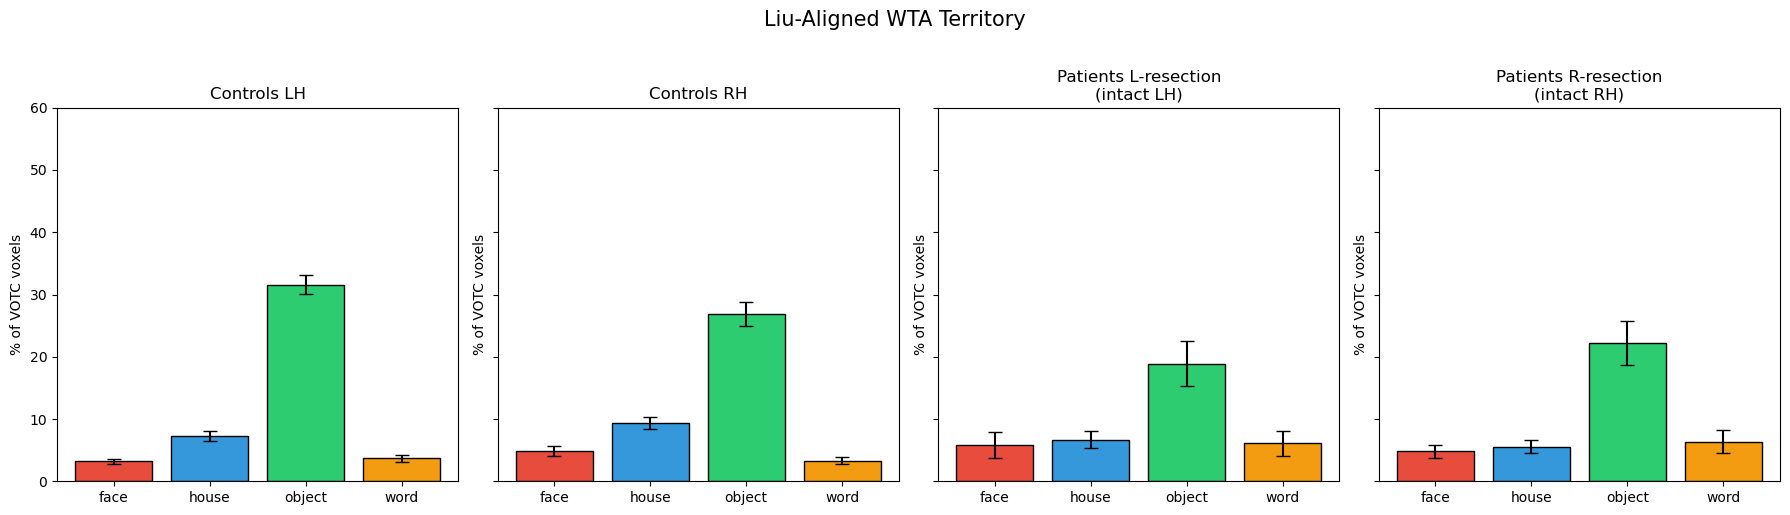

In [5]:
# Bar chart: average territory per category
panels = [
    ('Controls LH', 'control', 'l', None),
    ('Controls RH', 'control', 'r', None),
    ('Patients L-resection\n(intact LH)', 'OTC', 'l', 'right'),
    ('Patients R-resection\n(intact RH)', 'OTC', 'r', 'left'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
for ax, (title, group, hemi, surg) in zip(axes, panels):
    pct_rows = []
    for (sid, ses, h), res in wta_results.items():
        if res['group'] != group or h != hemi:
            continue
        if surg is not None and res.get('surgery_side', 'na') != surg:
            continue
        pct_rows.append(res['pcts'])

    if not pct_rows:
        ax.set_title(f'{title}\n(no data)')
        continue

    df = pd.DataFrame(pct_rows)
    means = df[CATEGORIES].mean()
    sems  = df[CATEGORIES].sem()
    ax.bar(CATEGORIES, means, yerr=sems, capsize=5,
           color=[CAT_COLORS[c] for c in CATEGORIES], edgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('% of VOTC voxels')
    ax.set_ylim(0, 60)

plt.suptitle('Liu-Aligned WTA Territory', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'wta_territory_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 2. Longitudinal Transition Matrices

In [6]:
transition_results = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        mask, _ = get_votc_mask(h)
        if mask is None:
            continue

        betas_t1 = load_category_betas(sid, t1_ses, mask)
        betas_t2 = load_category_betas(sid, t2_ses, mask)
        if betas_t1 is None or betas_t2 is None:
            continue

        winners_t1, margin_t1, _ = compute_wta(betas_t1, WTA_THRESHOLD)
        winners_t2, margin_t2, _ = compute_wta(betas_t2, WTA_THRESHOLD)
        trans, trans_pct, retention = compute_transition_matrix(winners_t1, winners_t2)

        transition_results[(sid, h)] = {
            'trans_counts': trans, 'trans_pct': trans_pct, 'retention': retention,
            'winners_t1': winners_t1, 'winners_t2': winners_t2,
            'margin_t1': margin_t1, 'margin_t2': margin_t2,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            't1_ses': t1_ses, 't2_ses': t2_ses, 'info': info,
        }

print(f'Transitions for {len(transition_results)} sub-hemi entries')

Transitions for 27 sub-hemi entries


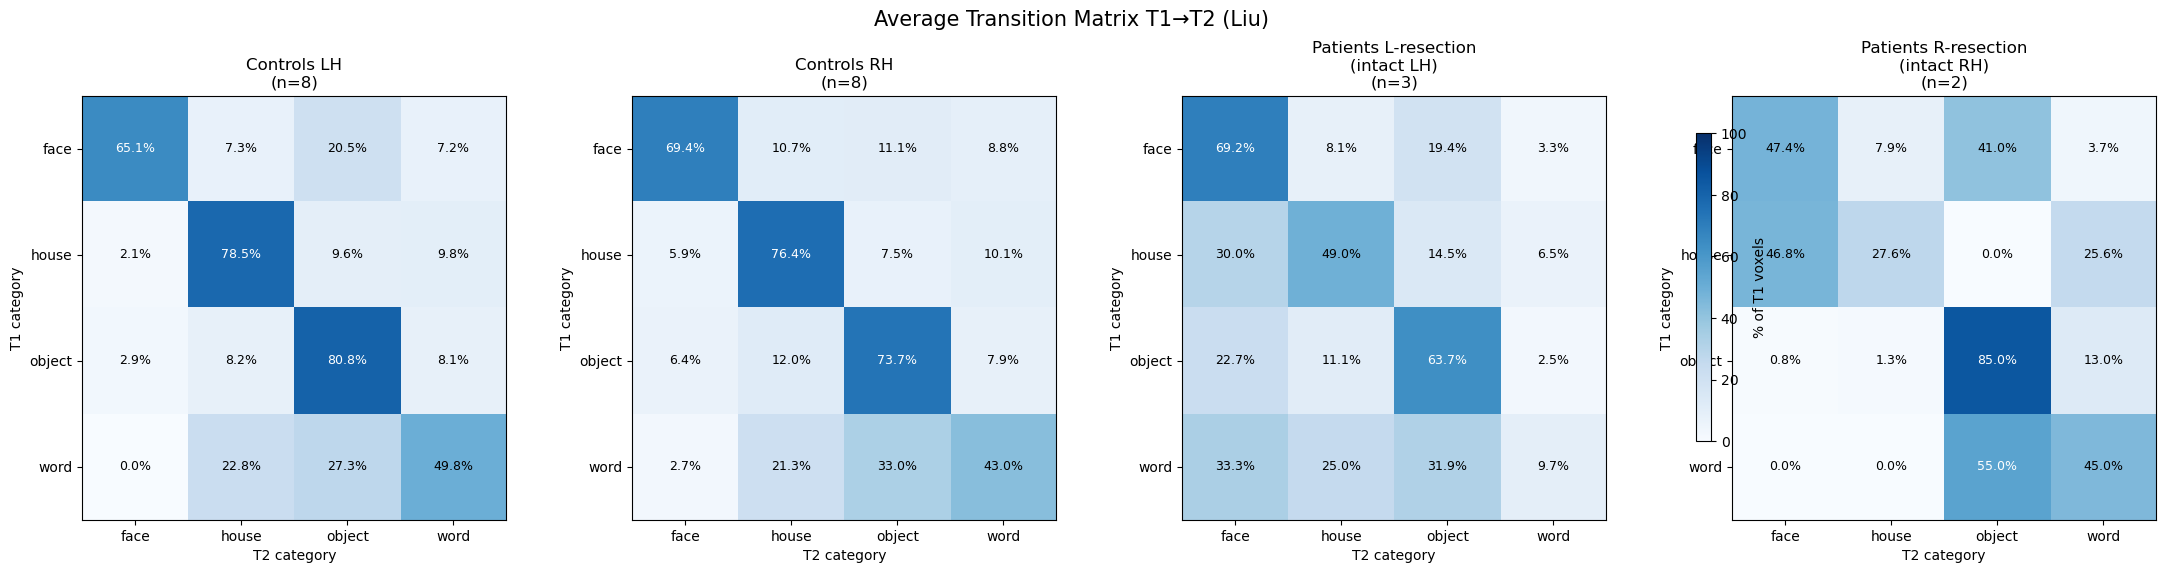

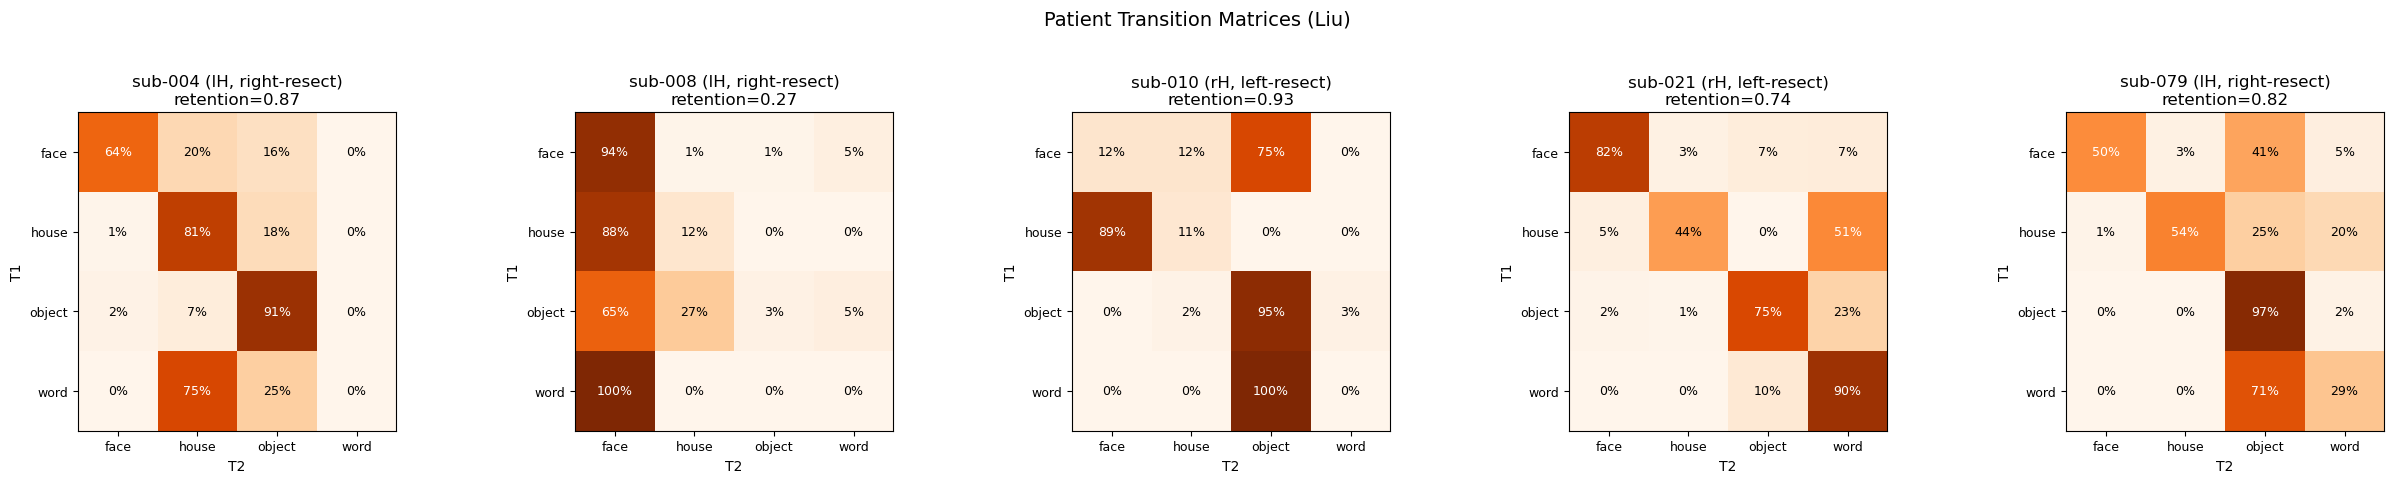

In [7]:
def avg_transition_matrix(results, group, hemi=None, surgery_side=None):
    matrices, sids = [], []
    for (sid, h), res in results.items():
        if res['group'] != group:
            continue
        if hemi is not None and h != hemi:
            continue
        if surgery_side is not None and res.get('surgery_side', 'na') != surgery_side:
            continue
        matrices.append(res['trans_pct'])
        sids.append(sid)
    if not matrices:
        return None, []
    return np.mean(matrices, axis=0), sids


panels = [
    ('Controls LH', 'control', 'l', None),
    ('Controls RH', 'control', 'r', None),
    ('Patients L-resection\n(intact LH)', 'OTC', 'l', 'right'),
    ('Patients R-resection\n(intact RH)', 'OTC', 'r', 'left'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (title, group, hemi, surg) in zip(axes, panels):
    avg_mat, sids = avg_transition_matrix(transition_results, group, hemi, surg)
    if avg_mat is None:
        ax.set_title(f'{title}\n(no data)'); ax.axis('off'); continue
    im = ax.imshow(avg_mat, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CATEGORIES); ax.set_yticklabels(CATEGORIES)
    ax.set_xlabel('T2 category'); ax.set_ylabel('T1 category')
    ax.set_title(f'{title}\n(n={len(sids)})')
    for i in range(4):
        for j in range(4):
            color = 'white' if avg_mat[i, j] > 50 else 'black'
            ax.text(j, i, f'{avg_mat[i, j]:.1f}%',
                    ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=axes, shrink=0.8, label='% of T1 voxels')
plt.suptitle('Average Transition Matrix T1→T2 (Liu)', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'transition_matrix_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Individual patient heatmaps
patient_trans = {k: v for k, v in transition_results.items() if v['group'] == 'OTC'}
if patient_trans:
    n_pt = len(patient_trans)
    fig, axes = plt.subplots(1, n_pt, figsize=(5 * n_pt, 4.5))
    if n_pt == 1: axes = [axes]
    for ax, ((sid, h), res) in zip(axes, patient_trans.items()):
        im = ax.imshow(res['trans_pct'], cmap='Oranges', vmin=0, vmax=100)
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(CATEGORIES, fontsize=9)
        ax.set_yticklabels(CATEGORIES, fontsize=9)
        ax.set_xlabel('T2'); ax.set_ylabel('T1')
        ax.set_title(f'{sid} ({h}H, {res.get("surgery_side", "?")}-resect)\n'
                     f'retention={res["retention"]:.2f}')
        for i in range(4):
            for j in range(4):
                color = 'white' if res['trans_pct'][i, j] > 50 else 'black'
                ax.text(j, i, f'{res["trans_pct"][i, j]:.0f}%',
                        ha='center', va='center', fontsize=9, color=color)
    plt.suptitle('Patient Transition Matrices (Liu)', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'patient_transitions_liu.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

## 3. Voxel Profile Stability

In [8]:
stability_results = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        mask, _ = get_votc_mask(h)
        if mask is None: continue
        betas_t1 = load_category_betas(sid, t1_ses, mask)
        betas_t2 = load_category_betas(sid, t2_ses, mask)
        if betas_t1 is None or betas_t2 is None: continue

        cs, mean_cs, median_cs = compute_profile_stability(betas_t1, betas_t2)
        stability_results[(sid, h)] = {
            'cos_sims': cs, 'mean_cos': mean_cs, 'median_cos': median_cs,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'), 'info': info,
        }

print(f'Profile stability for {len(stability_results)} entries')

stab_rows = [{'sub': sid, 'hemi': h, 'group': res['group'],
              'surgery_side': res.get('surgery_side', 'na'),
              'mean_cos_sim': res['mean_cos'], 'median_cos_sim': res['median_cos']}
             for (sid, h), res in stability_results.items()]
stab_df = pd.DataFrame(stab_rows)
print('\n=== PROFILE STABILITY ===\n')
print(stab_df.groupby(['group', 'surgery_side'])[['mean_cos_sim', 'median_cos_sim']]
      .describe().round(3))

Profile stability for 27 entries

=== PROFILE STABILITY ===

                     mean_cos_sim                                            \
                            count   mean    std    min    25%    50%    75%   
group   surgery_side                                                          
OTC     left                  2.0  0.307  0.239  0.138  0.222  0.307  0.391   
        right                 3.0  0.341  0.337 -0.046  0.229  0.504  0.534   
control na                   16.0  0.482  0.091  0.280  0.451  0.492  0.531   
nonOTC  left                  4.0  0.568  0.059  0.481  0.563  0.593  0.598   
        right                 2.0  0.557  0.032  0.535  0.546  0.557  0.569   

                            median_cos_sim                                     \
                        max          count   mean    std    min    25%    50%   
group   surgery_side                                                            
OTC     left          0.476            2.0  0.440  0.319  0.215

In [9]:
# Thresholded profile stability — only voxels selective at T1
STABILITY_THRESHOLD = WTA_THRESHOLD

thresh_stability = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        mask, _ = get_votc_mask(h)
        if mask is None: continue
        betas_t1 = load_category_betas(sid, t1_ses, mask)
        betas_t2 = load_category_betas(sid, t2_ses, mask)
        if betas_t1 is None or betas_t2 is None: continue

        mat_t1 = np.column_stack([betas_t1[c] for c in CATEGORIES])
        mat_t2 = np.column_stack([betas_t2[c] for c in CATEGORIES])

        max_t1 = np.max(mat_t1, axis=1)
        selective = max_t1 > STABILITY_THRESHOLD
        n_sel = int(selective.sum())
        if n_sel == 0: continue

        m1, m2 = mat_t1[selective], mat_t2[selective]
        dot = np.sum(m1 * m2, axis=1)
        n1 = np.linalg.norm(m1, axis=1)
        n2 = np.linalg.norm(m2, axis=1)
        denom = n1 * n2
        valid = denom > 0
        cs = np.full(n_sel, np.nan)
        cs[valid] = dot[valid] / denom[valid]

        winners_t1, _, _ = compute_wta(betas_t1, STABILITY_THRESHOLD)
        cat_cos = {}
        for i, cat in enumerate(CATEGORIES):
            combined = (winners_t1 == i) & selective
            if combined.sum() > 10:
                mc1, mc2 = mat_t1[combined], mat_t2[combined]
                d = np.sum(mc1 * mc2, axis=1)
                nn1 = np.linalg.norm(mc1, axis=1)
                nn2 = np.linalg.norm(mc2, axis=1)
                dd = nn1 * nn2; vv = dd > 0
                cc = np.full(combined.sum(), np.nan)
                cc[vv] = d[vv] / dd[vv]
                cat_cos[cat] = np.nanmean(cc)
            else:
                cat_cos[cat] = np.nan

        thresh_stability[(sid, h)] = {
            'cos_sims': cs, 'mean_cos': np.nanmean(cs),
            'median_cos': np.nanmedian(cs), 'cat_cos': cat_cos,
            'n_selective': n_sel, 'n_total': len(max_t1),
            'pct_selective': n_sel / len(max_t1) * 100,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'), 'hemi': h,
        }

print('=' * 70)
print(f'PROFILE STABILITY — THRESHOLDED (z > {STABILITY_THRESHOLD})')
print('=' * 70)
print(f'\n{"Sub":>10} {"Hemi":>5} {"Group":>8} {"N sel":>7} {"% sel":>6} '
      f'{"Thresh cos":>10} {"Orig cos":>10}')
for (sid, h), res in sorted(thresh_stability.items()):
    orig = stability_results.get((sid, h), {}).get('mean_cos', np.nan)
    print(f'{sid:>10} {h:>5} {res["group"]:>8} {res["n_selective"]:>7} '
          f'{res["pct_selective"]:>5.1f}% {res["mean_cos"]:>10.3f} {orig:>10.3f}')

PROFILE STABILITY — THRESHOLDED (z > 2.326)

       Sub  Hemi    Group   N sel  % sel Thresh cos   Orig cos
   sub-004     l      OTC    1843  16.0%      0.741      0.504
   sub-007     l   nonOTC    3921  34.0%      0.714      0.481
   sub-007     r   nonOTC    4448  39.2%      0.810      0.605
   sub-008     l      OTC    4123  35.7%     -0.052     -0.046
   sub-010     r      OTC    2653  23.4%      0.222      0.138
   sub-018     l  control    5523  47.9%      0.723      0.490
   sub-018     r  control    6260  55.2%      0.691      0.529
   sub-021     r      OTC    3884  34.3%      0.815      0.476
   sub-022     l  control    4554  39.5%      0.703      0.506
   sub-022     r  control    3695  32.6%      0.529      0.398
   sub-025     l  control    6564  56.9%      0.662      0.487
   sub-025     r  control    5543  48.9%      0.701      0.495
   sub-045     l   nonOTC    6485  56.2%      0.800      0.591
   sub-045     r   nonOTC    6268  55.3%      0.789      0.596
   sub-052

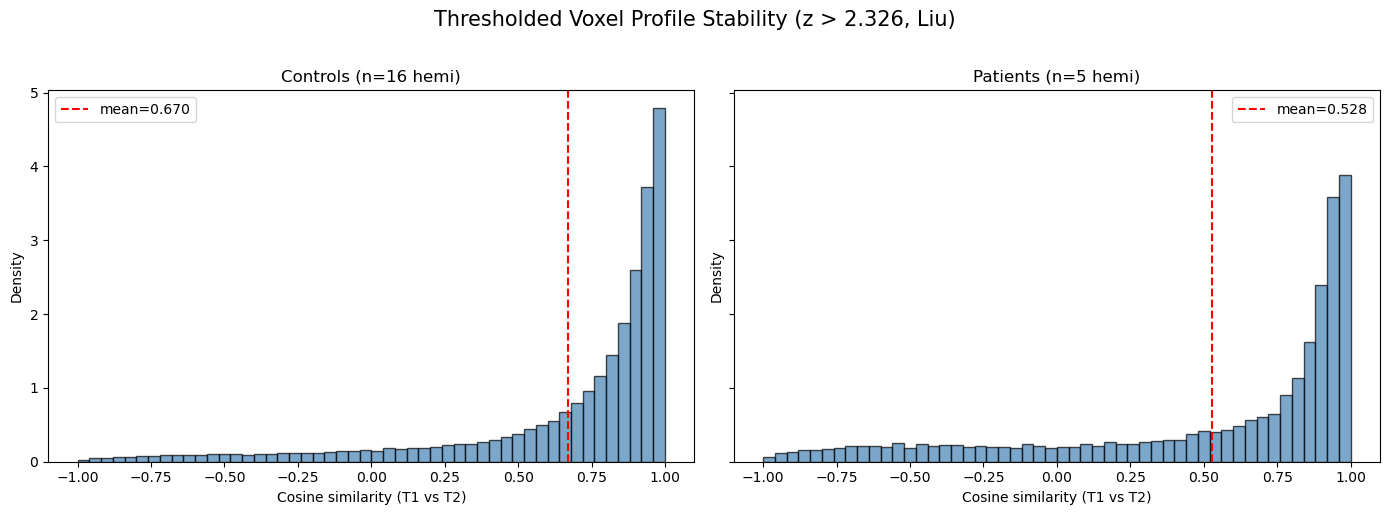


CRAWFORD'S t — Thresholded cosine (z > 2.326)

  sub-004 (LH, right-resection) — ANATOMICAL (vs Ctrl LH):
     overall: pt=0.741, ctrl=0.708, t=+0.27, p=0.7943
        face: pt=0.843, ctrl=0.544, t=+1.15, p=0.2878
       house: pt=0.650, ctrl=0.708, t=-0.33, p=0.7488
      object: pt=0.807, ctrl=0.760, t=+0.30, p=0.7736
  sub-004 (LH, right-resection) — FUNCTIONAL:
        face: pt=0.843, ctrl_RH=0.620, t=+0.97, p=0.3623
       house: pt=0.650, ctrl_both=0.702, t=-0.32, p=0.7536
      object: pt=0.807, ctrl_both=0.733, t=+0.46, p=0.6534

  sub-008 (LH, right-resection) — ANATOMICAL (vs Ctrl LH):
     overall: pt=-0.052, ctrl=0.708, t=-6.23, p=0.0004 *
        face: pt=0.029, ctrl=0.544, t=-1.98, p=0.0882
       house: pt=0.099, ctrl=0.708, t=-3.52, p=0.0097 *
      object: pt=-0.092, ctrl=0.760, t=-5.46, p=0.0009 *
        word: pt=-0.278, ctrl=0.661, t=-5.66, p=0.0008 *
  sub-008 (LH, right-resection) — FUNCTIONAL:
        face: pt=0.029, ctrl_RH=0.620, t=-2.59, p=0.0362 *
       hou

In [10]:
# Histogram + Crawford's t (anatomical + functional)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (title, group) in zip(axes, [('Controls', 'control'), ('Patients', 'OTC')]):
    all_cos = [r['cos_sims'] for r in thresh_stability.values() if r['group'] == group]
    if not all_cos:
        ax.set_title(f'{title} (no data)'); continue
    pooled = np.concatenate(all_cos)
    pooled = pooled[np.isfinite(pooled)]
    ax.hist(pooled, bins=50, range=(-1, 1), density=True, alpha=0.7,
            color='steelblue', edgecolor='black')
    ax.axvline(np.mean(pooled), color='red', linestyle='--',
               label=f'mean={np.mean(pooled):.3f}')
    ax.set_xlabel('Cosine similarity (T1 vs T2)')
    ax.set_ylabel('Density')
    ax.set_title(f'{title} (n={len(all_cos)} hemi)')
    ax.legend()

plt.suptitle(f'Thresholded Voxel Profile Stability (z > {STABILITY_THRESHOLD}, Liu)',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'profile_stability_thresh_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()

ctrl_cos_thresh = {'l': {c: [] for c in CATEGORIES},
                   'r': {c: [] for c in CATEGORIES}}
ctrl_overall_thresh = {'l': [], 'r': []}
for (sid, h), res in thresh_stability.items():
    if res['group'] != 'control': continue
    ctrl_overall_thresh[h].append(res['mean_cos'])
    for cat in CATEGORIES:
        v = res['cat_cos'].get(cat, np.nan)
        if np.isfinite(v):
            ctrl_cos_thresh[h][cat].append(v)

print('\n' + '=' * 70)
print(f"CRAWFORD'S t — Thresholded cosine (z > {STABILITY_THRESHOLD})")
print('=' * 70)

for (sid, h), res in sorted(thresh_stability.items()):
    if res['group'] != 'OTC': continue
    surgery = res['surgery_side']
    label = 'LH' if h == 'l' else 'RH'

    print(f'\n  {sid} ({label}, {surgery}-resection) — ANATOMICAL (vs Ctrl {label}):')
    pt_val = res['mean_cos']
    cv = np.array(ctrl_overall_thresh[h])
    if len(cv) >= 2:
        t, p = crawford_t(pt_val, cv)
        sig = ' *' if p < .05 else ''
        print(f'    {"overall":>8}: pt={pt_val:.3f}, ctrl={np.mean(cv):.3f}, '
              f't={t:+.2f}, p={p:.4f}{sig}')
    for cat in CATEGORIES:
        pv = res['cat_cos'].get(cat, np.nan)
        cv = np.array(ctrl_cos_thresh[h][cat])
        if not np.isfinite(pv) or len(cv) < 2: continue
        t, p = crawford_t(pv, cv); sig = ' *' if p < .05 else ''
        print(f'    {cat:>8}: pt={pv:.3f}, ctrl={np.mean(cv):.3f}, '
              f't={t:+.2f}, p={p:.4f}{sig}')

    print(f'  {sid} ({label}, {surgery}-resection) — FUNCTIONAL:')
    for cat in CATEGORIES:
        pv = res['cat_cos'].get(cat, np.nan)
        cv = np.array(get_functional_ctrl_vals(ctrl_cos_thresh, cat))
        if not np.isfinite(pv) or len(cv) < 2: continue
        t, p = crawford_t(pv, cv); sig = ' *' if p < .05 else ''
        fh = FUNCTIONAL_HEMI[cat]
        fl = 'both' if fh is None else ('LH' if fh == 'l' else 'RH')
        print(f'    {cat:>8}: pt={pv:.3f}, ctrl_{fl}={np.mean(cv):.3f}, '
              f't={t:+.2f}, p={p:.4f}{sig}')

## 4. Summed Selectivity (Liu contrasts)

In [11]:
sumsel_rows = []

for sid, info in long_subs.items():
    sessions = info['sessions']
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        mask, _ = get_votc_mask(h)
        if mask is None: continue
        mask_size = int(mask.sum())

        for ses in sessions:
            betas = load_category_betas(sid, ses, mask)
            if betas is None: continue
            ss = compute_summed_selectivity(betas, mask_size)
            for cat, vals in ss.items():
                sumsel_rows.append({
                    'sub': sid, 'ses': ses, 'hemi': h,
                    'group': info['patient_status'],
                    'surgery_side': info.get('surgery_side', 'na'),
                    'category': cat, **vals,
                })

sumsel_df = pd.DataFrame(sumsel_rows)
if not sumsel_df.empty:
    print('=== SUMMED SELECTIVITY (Liu contrasts) ===\n')
    for sid in sorted(long_subs.keys()):
        sub_df = sumsel_df[sumsel_df['sub'] == sid]
        if sub_df.empty: continue
        sessions = sorted(sub_df['ses'].unique())
        if len(sessions) < 2: continue

        group = long_subs[sid]['patient_status']
        surgery = long_subs[sid].get('surgery_side', 'na')
        print(f'\n{sid} ({group}, {surgery}-resection):')
        for cat in CATEGORIES:
            t1 = sub_df[(sub_df['ses'] == sessions[0]) & (sub_df['category'] == cat)]['summed_sel']
            t2 = sub_df[(sub_df['ses'] == sessions[-1]) & (sub_df['category'] == cat)]['summed_sel']
            if t1.empty or t2.empty: continue
            t1v, t2v = t1.iloc[0], t2.iloc[0]
            print(f'  {cat:8s}: T1={t1v:10.1f}  T2={t2v:10.1f}  Δ={t2v - t1v:+10.1f}')

=== SUMMED SELECTIVITY (Liu contrasts) ===


sub-004 (OTC, right-resection):
  face    : T1=    1250.2  T2=    4624.4  Δ=   +3374.2
  house   : T1=    6851.6  T2=    9919.3  Δ=   +3067.7
  object  : T1=    7463.9  T2=   16931.9  Δ=   +9468.0
  word    : T1=    1284.3  T2=     498.2  Δ=    -786.1

sub-007 (nonOTC, left-resection):
  face    : T1=    6552.1  T2=    5284.0  Δ=   -1268.1
  house   : T1=    9923.5  T2=    4438.6  Δ=   -5484.9
  object  : T1=   13481.8  T2=   15084.1  Δ=   +1602.3
  word    : T1=    1639.4  T2=    1670.1  Δ=     +30.7

sub-008 (OTC, right-resection):
  face    : T1=    7894.5  T2=    9496.1  Δ=   +1601.6
  house   : T1=    5536.9  T2=    5601.3  Δ=     +64.4
  object  : T1=   16449.3  T2=    2904.4  Δ=  -13544.9
  word    : T1=    4586.3  T2=    1238.0  Δ=   -3348.3

sub-010 (OTC, left-resection):
  face    : T1=    3533.6  T2=    2837.5  Δ=    -696.1
  house   : T1=    3726.8  T2=    2740.8  Δ=    -986.1
  object  : T1=   13645.3  T2=    7938.9  Δ=   -5706.

## 5. Margin Analysis

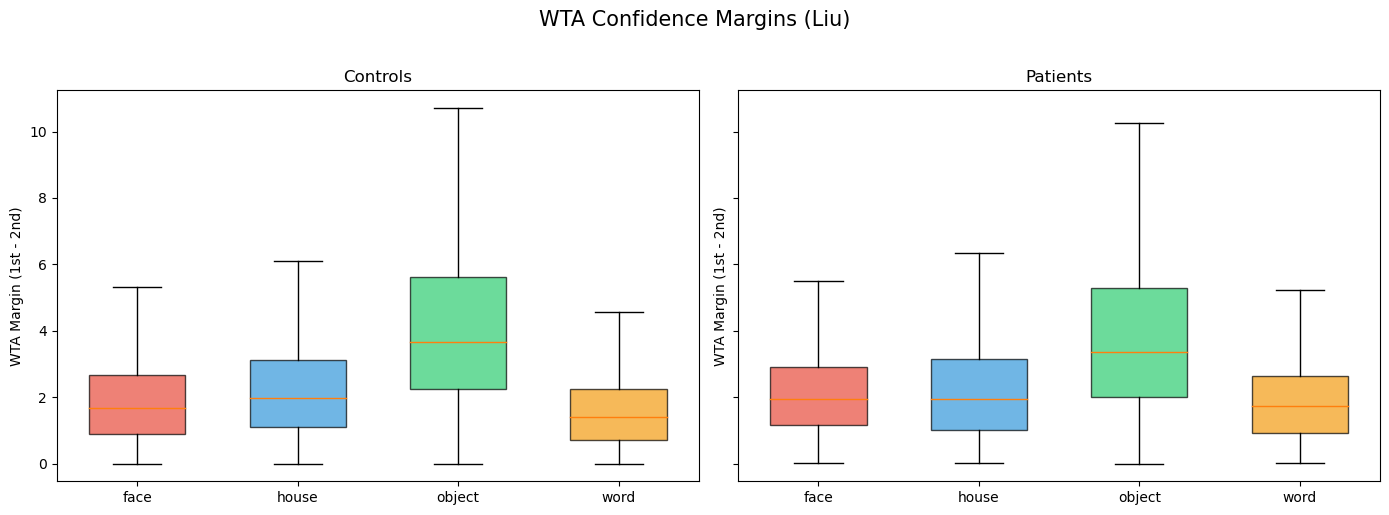


=== MARGIN CHANGE T1→T2 ===
Positive = more committed

category               face  house  object   word
group   surgery_side                             
OTC     left         -0.193 -0.413  -1.628 -0.535
        right        -0.861 -0.838  -0.182  0.377
control na            0.302  0.447  -0.946  0.219
nonOTC  left         -0.306 -1.891  -0.676 -0.155
        right         2.358  1.902   1.268 -0.534


In [12]:
# Cross-sectional margin distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (title, group) in zip(axes, [('Controls', 'control'), ('Patients', 'OTC')]):
    all_margins = {c: [] for c in CATEGORIES}
    for (sid, ses, h), res in wta_results.items():
        if res['group'] != group: continue
        for i, cat in enumerate(CATEGORIES):
            cm = res['winners'] == i
            if cm.sum() > 0:
                all_margins[cat].append(res['margin'][cm])

    positions, data, colors = [], [], []
    for i, cat in enumerate(CATEGORIES):
        if all_margins[cat]:
            data.append(np.concatenate(all_margins[cat]))
            positions.append(i); colors.append(CAT_COLORS[cat])
    if data:
        bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                        showfliers=False)
        for p, c in zip(bp['boxes'], colors):
            p.set_facecolor(c); p.set_alpha(0.7)
        ax.set_xticks(range(4)); ax.set_xticklabels(CATEGORIES)
    ax.set_ylabel('WTA Margin (1st - 2nd)')
    ax.set_title(title)

plt.suptitle('WTA Confidence Margins (Liu)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'wta_margins_liu.png'), dpi=150, bbox_inches='tight')
plt.show()

# Longitudinal margin change
margin_change_rows = []
for (sid, h), res in transition_results.items():
    for i, cat in enumerate(CATEGORIES):
        cm = res['winners_t1'] == i
        if cm.sum() == 0: continue
        m1 = np.mean(res['margin_t1'][cm])
        m2 = np.mean(res['margin_t2'][cm])
        margin_change_rows.append({
            'sub': sid, 'hemi': h,
            'group': res['group'],
            'surgery_side': res.get('surgery_side', 'na'),
            'category': cat,
            'mean_margin_t1': m1, 'mean_margin_t2': m2,
            'margin_change': m2 - m1, 'n_voxels': int(cm.sum()),
        })

margin_df = pd.DataFrame(margin_change_rows)
if not margin_df.empty:
    print('\n=== MARGIN CHANGE T1→T2 ===\nPositive = more committed\n')
    print(margin_df.pivot_table(values='margin_change',
                                 index=['group', 'surgery_side'],
                                 columns='category', aggfunc='mean').round(3))

## 6. Relocating vs. Resident Stability

In [13]:
all_cat_cos = {}

for (sid, h), res in stability_results.items():
    if (sid, h) not in transition_results: continue
    winners_t1 = transition_results[(sid, h)]['winners_t1']
    cs = res['cos_sims']
    cat_cos = {}
    for i, cat in enumerate(CATEGORIES):
        cm = winners_t1 == i
        cat_cos[cat] = np.nanmean(cs[cm]) if cm.sum() > 10 else np.nan
    all_cat_cos[(sid, h)] = {
        'cat_cos': cat_cos, 'group': res['group'],
        'surgery_side': res.get('surgery_side', 'na'), 'hemi': h,
    }

reloc_diff_rows = []
for (sid, h), info in all_cat_cos.items():
    cat_cos = info['cat_cos']
    relocating = 'face' if h == 'l' else 'word'
    residents = [c for c in CATEGORIES if c != relocating]
    rv = cat_cos.get(relocating, np.nan)
    rm = np.nanmean([cat_cos.get(c, np.nan) for c in residents])
    diff = rv - rm if np.isfinite(rv) and np.isfinite(rm) else np.nan
    reloc_diff_rows.append({
        'sub': sid, 'hemi': h, 'group': info['group'],
        'surgery_side': info['surgery_side'],
        'relocating': relocating,
        'reloc_cosine': rv, 'resident_mean_cosine': rm,
        'reloc_minus_resident': diff,
    })

reloc_df = pd.DataFrame(reloc_diff_rows)
print('=' * 70)
print('RELOCATING vs RESIDENT PROFILE STABILITY')
print('  LH: face (prefers RH) | RH: word (prefers LH)')
print('=' * 70)
print(f'\n{"Sub":>10} {"Hemi":>5} {"Group":>8} {"Reloc":>6} '
      f'{"Reloc cos":>10} {"Resid cos":>10} {"Diff":>8}')
for _, row in reloc_df.sort_values(['group', 'sub', 'hemi']).iterrows():
    print(f'{row["sub"]:>10} {row["hemi"]:>5} {row["group"]:>8} {row["relocating"]:>6} '
          f'{row["reloc_cosine"]:>10.3f} {row["resident_mean_cosine"]:>10.3f} '
          f'{row["reloc_minus_resident"]:>+8.3f}')

ctrl_diffs = {'l': [], 'r': []}
for _, row in reloc_df.iterrows():
    if row['group'] == 'control' and np.isfinite(row['reloc_minus_resident']):
        ctrl_diffs[row['hemi']].append(row['reloc_minus_resident'])

print('\n' + '=' * 70)
print("CRAWFORD'S t — Relocating-Resident difference vs Controls")
print('=' * 70)

for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    vals = ctrl_diffs[h]
    print(f'\nControl {label} (n={len(vals)}): M={np.mean(vals):+.3f} '
          f'SD={np.std(vals, ddof=1):.3f}' if len(vals) > 1
          else f'\nControl {label}: insufficient n')

for _, row in reloc_df.sort_values('sub').iterrows():
    if row['group'] != 'OTC' or not np.isfinite(row['reloc_minus_resident']): continue
    h = row['hemi']
    cv = np.array(ctrl_diffs[h])
    if len(cv) < 2: continue
    pv = row['reloc_minus_resident']
    t, p = crawford_t(pv, cv); sig = ' *' if p < .05 else ''
    label = 'LH' if h == 'l' else 'RH'
    print(f'  {row["sub"]} ({label}, reloc={row["relocating"]}): '
          f'diff={pv:+.3f}, t={t:+.2f}, p={p:.4f}{sig}')

RELOCATING vs RESIDENT PROFILE STABILITY
  LH: face (prefers RH) | RH: word (prefers LH)

       Sub  Hemi    Group  Reloc  Reloc cos  Resid cos     Diff
   sub-004     l      OTC   face      0.843      0.729   +0.115
   sub-008     l      OTC   face      0.029     -0.090   +0.119
   sub-010     r      OTC   word     -0.400     -0.023   -0.377
   sub-021     r      OTC   word      0.044      0.836   -0.792
   sub-079     l      OTC   face      0.451      0.683   -0.231
   sub-018     l  control   face      0.568      0.623   -0.055
   sub-018     r  control   word      0.254      0.673   -0.419
   sub-022     l  control   face      0.403      0.687   -0.284
   sub-022     r  control   word      0.439      0.628   -0.189
   sub-025     l  control   face      0.226      0.624   -0.398
   sub-025     r  control   word      0.613      0.579   +0.034
   sub-052     l  control   face      0.784      0.667   +0.117
   sub-052     r  control   word      0.532      0.627   -0.095
   sub-058    

## 7. Statistics — Anatomical vs Functional Homolog

In [14]:
ret_rows = []
for sid, info in long_subs.items():
    group = info['patient_status']
    surgery = info.get('surgery_side', 'na')
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']

    for h in hemis:
        if (sid, h) not in transition_results: continue
        res = transition_results[(sid, h)]
        tc = res['trans_counts']
        row = {'sub': sid, 'hemi': h, 'group': group, 'surgery_side': surgery,
               'overall_retention': res['retention']}
        for i, cat in enumerate(CATEGORIES):
            rt = tc[i, :].sum()
            row[f'{cat}_retention'] = tc[i, i] / rt if rt > 0 else np.nan
        if (sid, h) in all_cat_cos:
            for cat in CATEGORIES:
                row[f'{cat}_cosine'] = all_cat_cos[(sid, h)]['cat_cos'].get(cat, np.nan)
        if (sid, h) in stability_results:
            row['mean_cos_sim'] = stability_results[(sid, h)]['mean_cos']
        ret_rows.append(row)

ret_subject = pd.DataFrame(ret_rows)
ctrl_ret = ret_subject[ret_subject['group'] == 'control']
otc_ret  = ret_subject[ret_subject['group'] == 'OTC']

ctrl_ret_by_hemi = {'l': {c: [] for c in CATEGORIES + ['overall']},
                    'r': {c: [] for c in CATEGORIES + ['overall']}}
for _, row in ctrl_ret.iterrows():
    h = row['hemi']
    ctrl_ret_by_hemi[h]['overall'].append(row['overall_retention'])
    for cat in CATEGORIES:
        v = row[f'{cat}_retention']
        if np.isfinite(v):
            ctrl_ret_by_hemi[h][cat].append(v)

ctrl_cos_by_hemi = {'l': {c: [] for c in CATEGORIES},
                    'r': {c: [] for c in CATEGORIES}}
for (sid, h), info in all_cat_cos.items():
    if info['group'] != 'control': continue
    for cat in CATEGORIES:
        v = info['cat_cos'].get(cat, np.nan)
        if np.isfinite(v):
            ctrl_cos_by_hemi[h][cat].append(v)

ctrl_ret_functional = {cat: get_functional_ctrl_vals(ctrl_ret_by_hemi, cat)
                       for cat in CATEGORIES}

print(f'Retention table: {len(ret_subject)} entries '
      f'({len(ctrl_ret)} ctrl, {len(otc_ret)} OTC)')

Retention table: 27 entries (16 ctrl, 5 OTC)


### 7a. Anatomical Homolog: Retention

In [15]:
print('=' * 70)
print('ANATOMICAL HOMOLOG: Per-category retention')
print('Patient intact LH → Control LH | Patient intact RH → Control RH')
print('=' * 70)

print('\n--- Group means [95% CI], by hemisphere ---')
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    print(f'\n  {label}:')
    for cat in CATEGORIES + ['overall']:
        col = f'{cat}_retention' if cat != 'overall' else 'overall_retention'
        cv = ctrl_ret_by_hemi[h][cat]
        otc_h = otc_ret[otc_ret['hemi'] == h]
        ov = otc_h[col].dropna().values
        if len(cv) >= 2:
            m, lo, hi = bootstrap_ci(cv)
            print(f'    Ctrl {cat:>8} (n={len(cv)}): {m:.3f} [{lo:.3f}, {hi:.3f}]')
        if len(ov) >= 1:
            print(f'    OTC  {cat:>8} (n={len(ov)}): {np.nanmean(ov):.3f}')

print('\n' + '=' * 70)
print("CRAWFORD'S t: each OTC patient vs hemi-matched controls (ANATOMICAL)")
print('=' * 70)

for _, row in otc_ret.iterrows():
    sub, h, surgery = row['sub'], row['hemi'], row['surgery_side']
    label = 'LH' if h == 'l' else 'RH'
    print(f'\n  {sub} ({label}, {surgery}-resection):')
    for cat in CATEGORIES + ['overall']:
        col = f'{cat}_retention' if cat != 'overall' else 'overall_retention'
        pv = row[col]
        cv = np.array(ctrl_ret_by_hemi[h][cat])
        if not np.isfinite(pv) or len(cv) < 2: continue
        t, p = crawford_t(pv, cv); sig = ' *' if p < .05 else ''
        print(f'    {cat:>8}: val={pv:.3f}, ctrl={np.mean(cv):.3f}, '
              f't={t:+.2f}, p={p:.4f}{sig}')

ANATOMICAL HOMOLOG: Per-category retention
Patient intact LH → Control LH | Patient intact RH → Control RH

--- Group means [95% CI], by hemisphere ---

  LH:
    Ctrl     face (n=8): 0.651 [0.451, 0.794]
    OTC      face (n=3): 0.692
    Ctrl    house (n=8): 0.785 [0.637, 0.920]
    OTC     house (n=3): 0.490
    Ctrl   object (n=8): 0.808 [0.738, 0.879]
    OTC    object (n=3): 0.637
    Ctrl     word (n=8): 0.498 [0.319, 0.678]
    OTC      word (n=3): 0.097
    Ctrl  overall (n=8): 0.765 [0.732, 0.798]
    OTC   overall (n=3): 0.652

  RH:
    Ctrl     face (n=8): 0.694 [0.502, 0.853]
    OTC      face (n=2): 0.474
    Ctrl    house (n=8): 0.764 [0.630, 0.885]
    OTC     house (n=2): 0.276
    Ctrl   object (n=8): 0.737 [0.640, 0.846]
    OTC    object (n=2): 0.850
    Ctrl     word (n=8): 0.430 [0.236, 0.652]
    OTC      word (n=2): 0.450
    Ctrl  overall (n=8): 0.689 [0.638, 0.743]
    OTC   overall (n=2): 0.832

CRAWFORD'S t: each OTC patient vs hemi-matched controls (ANATOM

### 7b. Functional Homolog: Retention

In [16]:
print('=' * 70)
print('FUNCTIONAL HOMOLOG: Per-category retention')
print('=' * 70)

print('\n--- Functional homolog control distributions ---')
for cat in CATEGORIES:
    fh = FUNCTIONAL_HEMI[cat]
    label = 'both' if fh is None else ('LH' if fh == 'l' else 'RH')
    vals = ctrl_ret_functional[cat]
    if vals:
        m, lo, hi = bootstrap_ci(vals)
        print(f'  {cat:>8} (Ctrl {label}, n={len(vals)}): {m:.3f} [{lo:.3f}, {hi:.3f}]')

print('\n' + '=' * 70)
print("CRAWFORD'S t: each OTC patient vs functional-homolog controls")
print('=' * 70)

for _, row in otc_ret.iterrows():
    sub, h, surgery = row['sub'], row['hemi'], row['surgery_side']
    label = 'LH' if h == 'l' else 'RH'
    print(f'\n  {sub} (intact {label}, {surgery}-resection):')
    for cat in CATEGORIES:
        pv = row[f'{cat}_retention']
        cv = np.array(ctrl_ret_functional[cat])
        if not np.isfinite(pv) or len(cv) < 2: continue
        t, p = crawford_t(pv, cv); sig = ' *' if p < .05 else ''
        fh = FUNCTIONAL_HEMI[cat]
        fl = 'both' if fh is None else ('LH' if fh == 'l' else 'RH')
        print(f'    {cat:>8}: val={pv:.3f}, ctrl_{fl}={np.mean(cv):.3f}, '
              f't={t:+.2f}, p={p:.4f}{sig}')

FUNCTIONAL HOMOLOG: Per-category retention

--- Functional homolog control distributions ---
      face (Ctrl RH, n=8): 0.694 [0.509, 0.851]
     house (Ctrl both, n=16): 0.774 [0.676, 0.869]
    object (Ctrl both, n=16): 0.772 [0.706, 0.838]
      word (Ctrl LH, n=8): 0.498 [0.323, 0.682]

CRAWFORD'S t: each OTC patient vs functional-homolog controls

  sub-004 (intact LH, right-resection):
        face: val=0.640, ctrl_RH=0.694, t=-0.19, p=0.8534
       house: val=0.811, ctrl_both=0.774, t=+0.18, p=0.8600
      object: val=0.910, ctrl_both=0.772, t=+0.97, p=0.3489
        word: val=0.000, ctrl_LH=0.498, t=-1.67, p=0.1393

  sub-008 (intact LH, right-resection):
        face: val=0.936, ctrl_RH=0.694, t=+0.86, p=0.4189
       house: val=0.122, ctrl_both=0.774, t=-3.18, p=0.0062 *
      object: val=0.028, ctrl_both=0.772, t=-5.24, p=0.0001 *
        word: val=0.000, ctrl_LH=0.498, t=-1.67, p=0.1393

  sub-010 (intact RH, left-resection):
        face: val=0.125, ctrl_RH=0.694, t=-2.02,

### 7c. Per-Category Cosine Stability — both frameworks

In [17]:
print('=' * 70)
print('PER-CATEGORY COSINE: ANATOMICAL HOMOLOG')
print('=' * 70)

for (sid, h), info in sorted(all_cat_cos.items()):
    if info['group'] != 'OTC': continue
    surgery = info['surgery_side']
    label = 'LH' if h == 'l' else 'RH'
    print(f'\n  {sid} ({label}, {surgery}-resection) vs Control {label}:')
    for cat in CATEGORIES:
        pv = info['cat_cos'].get(cat, np.nan)
        cv = np.array(ctrl_cos_by_hemi[h][cat])
        if not np.isfinite(pv) or len(cv) < 2:
            print(f'    {cat:>8}: insufficient data'); continue
        t, p = crawford_t(pv, cv); sig = ' *' if p < .05 else ''
        print(f'    {cat:>8}: pt={pv:.3f}, ctrl={np.mean(cv):.3f}, '
              f't={t:+.2f}, p={p:.4f}{sig}')

print('\n' + '=' * 70)
print('PER-CATEGORY COSINE: FUNCTIONAL HOMOLOG')
print('=' * 70)

for (sid, h), info in sorted(all_cat_cos.items()):
    if info['group'] != 'OTC': continue
    surgery = info['surgery_side']
    label = 'LH' if h == 'l' else 'RH'
    print(f'\n  {sid} (intact {label}, {surgery}-resection):')
    for cat in CATEGORIES:
        pv = info['cat_cos'].get(cat, np.nan)
        cv = np.array(get_functional_ctrl_vals(ctrl_cos_by_hemi, cat))
        if not np.isfinite(pv) or len(cv) < 2:
            print(f'    {cat:>8}: insufficient data'); continue
        t, p = crawford_t(pv, cv); sig = ' *' if p < .05 else ''
        fh = FUNCTIONAL_HEMI[cat]
        fl = 'both' if fh is None else ('LH' if fh == 'l' else 'RH')
        print(f'    {cat:>8}: pt={pv:.3f}, ctrl_{fl}={np.mean(cv):.3f}, '
              f't={t:+.2f}, p={p:.4f}{sig}')

PER-CATEGORY COSINE: ANATOMICAL HOMOLOG

  sub-004 (LH, right-resection) vs Control LH:
        face: pt=0.843, ctrl=0.544, t=+1.15, p=0.2878
       house: pt=0.650, ctrl=0.708, t=-0.33, p=0.7488
      object: pt=0.807, ctrl=0.760, t=+0.30, p=0.7736
        word: insufficient data

  sub-008 (LH, right-resection) vs Control LH:
        face: pt=0.029, ctrl=0.544, t=-1.98, p=0.0882
       house: pt=0.099, ctrl=0.708, t=-3.52, p=0.0097 *
      object: pt=-0.092, ctrl=0.760, t=-5.46, p=0.0009 *
        word: pt=-0.278, ctrl=0.661, t=-5.66, p=0.0008 *

  sub-010 (RH, left-resection) vs Control RH:
        face: pt=-0.120, ctrl=0.620, t=-3.24, p=0.0143 *
       house: pt=-0.272, ctrl=0.695, t=-5.75, p=0.0007 *
      object: pt=0.322, ctrl=0.706, t=-2.12, p=0.0718
        word: pt=-0.400, ctrl=0.554, t=-4.49, p=0.0028 *

  sub-021 (RH, left-resection) vs Control RH:
        face: pt=0.840, ctrl=0.620, t=+0.96, p=0.3694
       house: pt=0.845, ctrl=0.695, t=+0.89, p=0.4016
      object: pt=0.

### 7d. Retention visualization — side-by-side

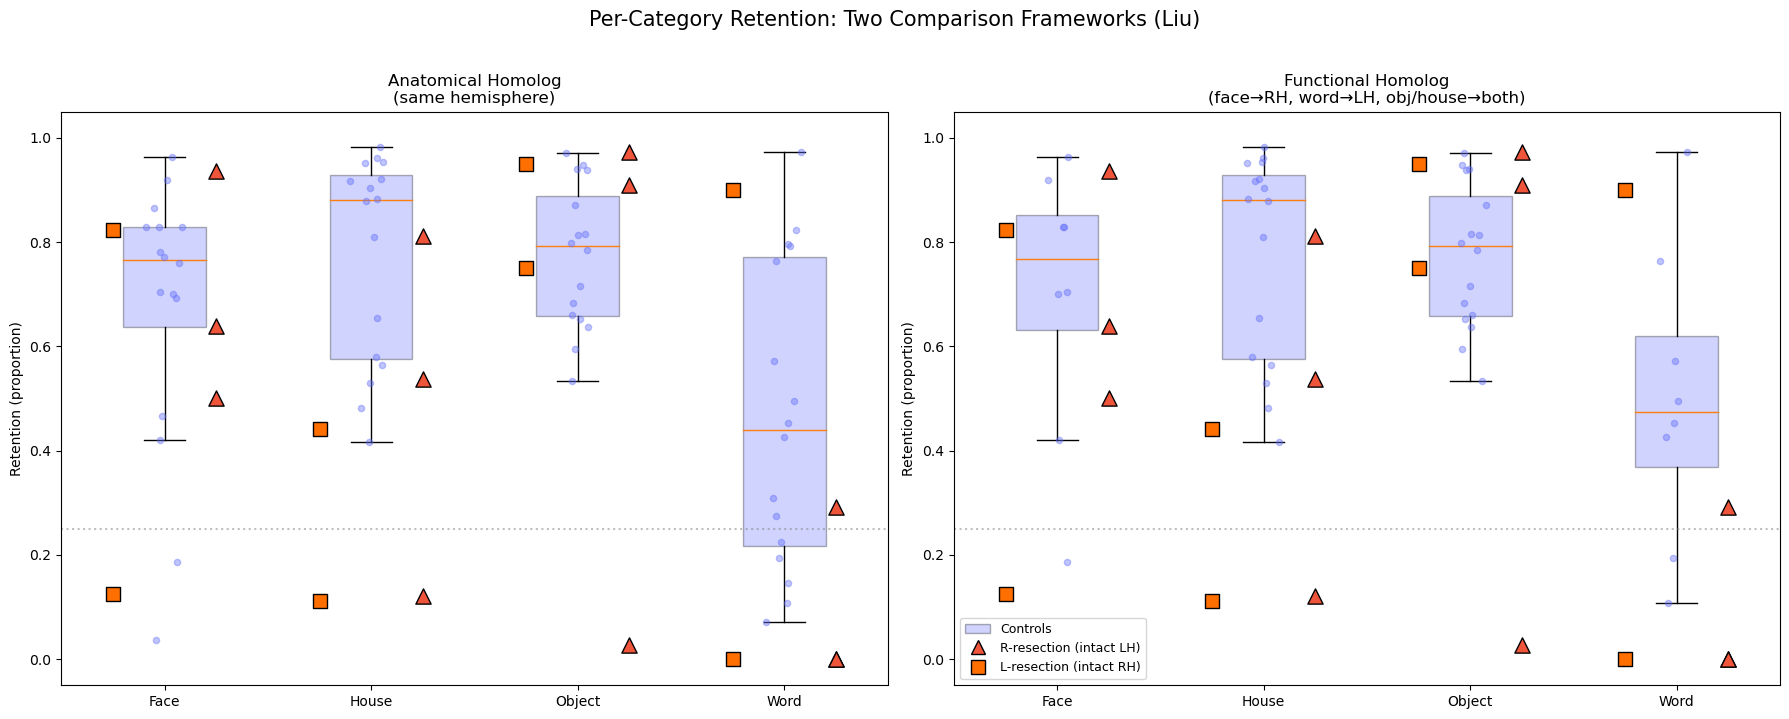

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
otc_R = otc_ret[otc_ret['surgery_side'] == 'right']
otc_L = otc_ret[otc_ret['surgery_side'] == 'left']

for panel_idx, (ax, title, ctrl_data_list) in enumerate(zip(
    axes,
    ['Anatomical Homolog\n(same hemisphere)',
     'Functional Homolog\n(face→RH, word→LH, obj/house→both)'],
    [[ctrl_ret_by_hemi['l'][cat] + ctrl_ret_by_hemi['r'][cat] for cat in CATEGORIES],
     [ctrl_ret_functional[cat] for cat in CATEGORIES]]
)):
    x = np.arange(len(CATEGORIES))
    bp = ax.boxplot(ctrl_data_list, positions=x, widths=0.4, patch_artist=True,
                    showfliers=False, zorder=1)
    for patch in bp['boxes']:
        patch.set_facecolor('#636EFA'); patch.set_alpha(0.3)

    for i, cat in enumerate(CATEGORIES):
        vals = ctrl_data_list[i]
        jitter = np.random.normal(0, 0.04, size=len(vals))
        ax.scatter(x[i] + jitter, vals, color='#636EFA', alpha=0.4, s=20, zorder=2)

    for _, row in otc_R.iterrows():
        for i, cat in enumerate(CATEGORIES):
            v = row[f'{cat}_retention']
            if np.isfinite(v):
                ax.scatter(x[i] + 0.25, v, marker='^', s=120,
                          color='#EF553B', edgecolor='black', linewidth=1, zorder=3)
    for _, row in otc_L.iterrows():
        for i, cat in enumerate(CATEGORIES):
            v = row[f'{cat}_retention']
            if np.isfinite(v):
                ax.scatter(x[i] - 0.25, v, marker='s', s=100,
                          color='#FF6F00', edgecolor='black', linewidth=1, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in CATEGORIES])
    ax.set_ylabel('Retention (proportion)')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title)
    ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5)

legend_elements = [
    Patch(facecolor='#636EFA', alpha=0.3, edgecolor='black', label='Controls'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#EF553B',
           markeredgecolor='black', markersize=10, label='R-resection (intact LH)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#FF6F00',
           markeredgecolor='black', markersize=10, label='L-resection (intact RH)'),
]
axes[1].legend(handles=legend_elements, fontsize=9, loc='lower left')

plt.suptitle('Per-Category Retention: Two Comparison Frameworks (Liu)',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'retention_anat_vs_func_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Table

In [19]:
summary_rows = []
for sid, info in long_subs.items():
    hemis = [info['hemi']] if info['patient_status'] == 'OTC' else ['l', 'r']
    for h in hemis:
        row = {'sub': sid, 'hemi': h,
               'group': info['patient_status'],
               'surgery_side': info.get('surgery_side', 'na')}
        if (sid, h) in transition_results:
            row['overall_retention'] = transition_results[(sid, h)]['retention']
            tc = transition_results[(sid, h)]['trans_counts']
            for i, cat in enumerate(CATEGORIES):
                rt = tc[i, :].sum()
                row[f'{cat}_retention'] = tc[i, i] / rt if rt > 0 else np.nan
        if (sid, h) in stability_results:
            row['mean_cos_sim'] = stability_results[(sid, h)]['mean_cos']
            row['median_cos_sim'] = stability_results[(sid, h)]['median_cos']
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
out_path = os.path.join(OUT_DIR, 'voxel_allegiance_summary_liu.csv')
summary_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print()
print(summary_df.to_string(index=False))

Saved: /user_data/csimmon2/sym_pt/group_results/voxel_allegiance_liu/voxel_allegiance_summary_liu.csv

    sub hemi   group surgery_side  overall_retention  face_retention  house_retention  object_retention  word_retention  mean_cos_sim  median_cos_sim
sub-004    l     OTC        right           0.866436        0.640000         0.811321          0.909707        0.000000      0.504131        0.619346
sub-007    l  nonOTC         left           0.872108        0.638225         0.734540          0.990793        0.000000      0.480602        0.648929
sub-007    r  nonOTC         left           0.865414        0.779930         0.800527          0.953016        0.000000      0.604672        0.786470
sub-008    l     OTC        right           0.269450        0.936000         0.121622          0.027778        0.000000     -0.046299       -0.079862
sub-010    r     OTC         left           0.926045        0.125000         0.111111          0.950331        0.000000      0.137507        0.2145

## Notes

**Liu contrasts** for WTA: face=cope1 (Face>Object), house=cope2, object=cope3, word=−cope13.

These are differential contrasts with different reference categories. Interpret WTA "winners" as
"voxels where category X's Liu contrast is strongest" — not "voxels selective for X over baseline."

For RSA / multivoxel pattern analyses → use raw beta copes 15-18 (separate notebook).

**Threshold:** z > 2.326 (p<.01 one-tailed), matches Liu sum-selectivity threshold.